## test_nuradio_single.py

### Basic Workflow
1. create a wrapper with a constructor\
`reader = NuRadioRecoReader(det, filt_settings)`
2. Read event \
`evt = reader.read_data_event_with_noise(filename, Tnoise)`
3. Apply analysis

### Event Object
**Station** object
- obtained by an iterator `evt.get_stations()`
- methods include `get_id()`, `iter_channels()`, `get_sim_station()`

**Channel** object
- Iterated in `station.iter_channels()`
- Contains traces
- Methods include: `get_trace()`, `get_times()`, `get_sampling_rate()`, `get_id()`

**sim_station** object
- Obtained by `station.get_sim_station()`
- Contains "true" electric field
- Methods include: `get_electric_fields()` returning an array(?) of ElectricField object

**EField** object
- `get_trace()` returns Ex, Ey, Ez components

### Functions defined
**__init__(self, det, filt_settings, sky_model="gsm2008")**\
Wrapper module to read in NuRadioReco events from CoREAS simulations with applied antenna response, bandpass, and noise, and optionally simulating the trigger and signal reconstruction. \
This can be used to read events to be applied to any reconstruction, such as a fluence-based reconstruction.

*Parameters*:
- det: NuRadioReco.detector.Detector object\
&emsp; The detector object containing the station and antenna information.\
- filt_settings: dict\
&emsp; The settings for the bandpass filter to be applied to the electric field and voltage traces.\
&emsp; Example: `filter_settings = {
    "passband": [30 * units.MHz, 80 * units.MHz],
    "filter_type": "butter",
    "order": 10,
}`

**__initialize_modules(self, sky_model="gsm2008")**\
Initializes all required modules from NuRadio. This includes:
- bandpass filter in Efield level
- Signal reconstruction from Voltage to Electric Field
- Galactic noise adder in Efield level
- Voltage to Electric Field converter in Efield level
- Generic noise adder in Voltage level
- Trigger simulator
- Bandpass filter in Voltage level
- Event type identifier
- Signal reconstructor in Voltage level
- coreas reader

**read_data_event_with_noise(self, in_file, site="lofar", Tnoise=300 * units.K, core=np.array([0, 0, 0]) * units.m, selected_station_channel_ids = None)**\
Read in a single event from the CoREAS simulation, apply the antenna response, bandpass filter, and noise, and simulate the trigger and signal reconstruction. This is useful for testing the fluence reconstruction on a "realistic" signal with noise and trigger effects included.

**plot_all_traces(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot all traces for each station, split by the channel orientation.

*Parameters*:
- my_event : Event\
&emsp; The event to plot traces for\
- my_detector : Detector\
&emsp; The detector description\
- title : str, optional\
&emsp; Title to give to the plot

**plot_footprint(self, my_event, my_detector, savefig_path=None)**\
Given an event and a detector description, plot the footprint of the event.

*Parameters*
- my_event : Event\
&emsp; The event to plot the footprint for
- my_detector : Detector\
&emsp; The detector description
- title : str, optional\
&emsp; Title to give to the plot

In [1]:
from test_nuradio_single import NuRadioRecoReader
from NuRadioReco.detector import detector
from NuRadioReco.utilities import units
from NuRadioReco.detector.antennapattern import preprocess_LOFAR_txt
import datetime
import numpy as np
import matplotlib.pyplot as plt

ERROR - 2026-08-11 10:33:07,831 - NuRadioReco.channelGalacticNoiseAdder - pylfmap import failed. This might be because you do not have a working installation of cfitsio. See https://github.com/F-Tomas/pylfmap/issues/2 for potential tips


In [2]:
path_to_response = "/home/rkitahara/Research/Cov/test_simulation/antenna_response_lofar"

path_to_coreas_sim_file = "/home/rkitahara/Research/Cov/test_simulation/93970574/0/proton/SIM000018.hdf5"

det = detector.Detector(
    "LOFAR/LOFAR.json", source="json", antenna_by_depth=False
)
det.update(datetime.datetime(2013, 1, 1, 0, 0, 0))

selected_station_channel_ids = {}
for staid in [1, 2, 3, 4, 5, 6, 7]:
    selected_station_channel_ids[staid] = det.get_channel_ids(staid)
# for staid in [1, 2]:
#     selected_station_channel_ids[staid] = det.get_channel_ids(staid)

core_xy = np.array([0, 0]) * units.m

preprocess_LOFAR_txt(path_to_response, orientation="Y")
preprocess_LOFAR_txt(path_to_response, orientation="X")

In [3]:
reader = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})

evt = reader.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=300 * units.K)

WARNING - 2026-08-11 10:33:33,624 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,625 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,625 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,626 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,626 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,626 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-08-11 10:33:33,627 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-08-11 10:33:34,985 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,985 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,986 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,986 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,986 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,987 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-08-11 10:33:34,987 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-08-11 10:33:38,782 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,783 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,783 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,784 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,784 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,784 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-08-11 10:33:38,785 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-08-11 10:33:48,131 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,132 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,132 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,132 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,133 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,133 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-08-11 10:33:48,134 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


WARNING - 2026-08-11 10:33:50,585 - NuRadioReco.detector - Cable delay not set for channel 7000000 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,586 - NuRadioReco.detector - Cable delay not set for channel 7000001 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,586 - NuRadioReco.detector - Cable delay not set for channel 7000002 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,587 - NuRadioReco.detector - Cable delay not set for channel 7000003 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,587 - NuRadioReco.detector - Cable delay not set for channel 7000004 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,587 - NuRadioReco.detector - Cable delay not set for channel 7000005 in station 7, assuming cable delay is zero
WARNING - 2026-08-11 10:33:50,588 - NuRadioReco.detector - Cable delay not set for channel 7000006 in station 7, assuming cable delay is zero
WARNIN

Calculated Vrms: 3.22e-06 V, applying noise with amplitude 4.55e-06 V


In [19]:
def detect_signal(evt, threshold=1e-3):
    plt.figure(figsize=(15,6))
    for stn in evt.get_stations():
        for chn in stn.iter_channels():
            trace = chn.get_trace()
            if np.max(trace) > threshold:
                print(f"{stn.get_id()}-{chn.get_id()}")
                plt.plot(trace, label=f"{stn.get_id()}-{chn.get_id()}")

    plt.legend()
    plt.show()

2-2001014
2-2002016
2-2005040
2-2005042
2-2900001
2-2900007
2-2902023
2-2903025
2-2905047
2-2906049
2-2909077
2-2909079
2-2910081
2-2910083


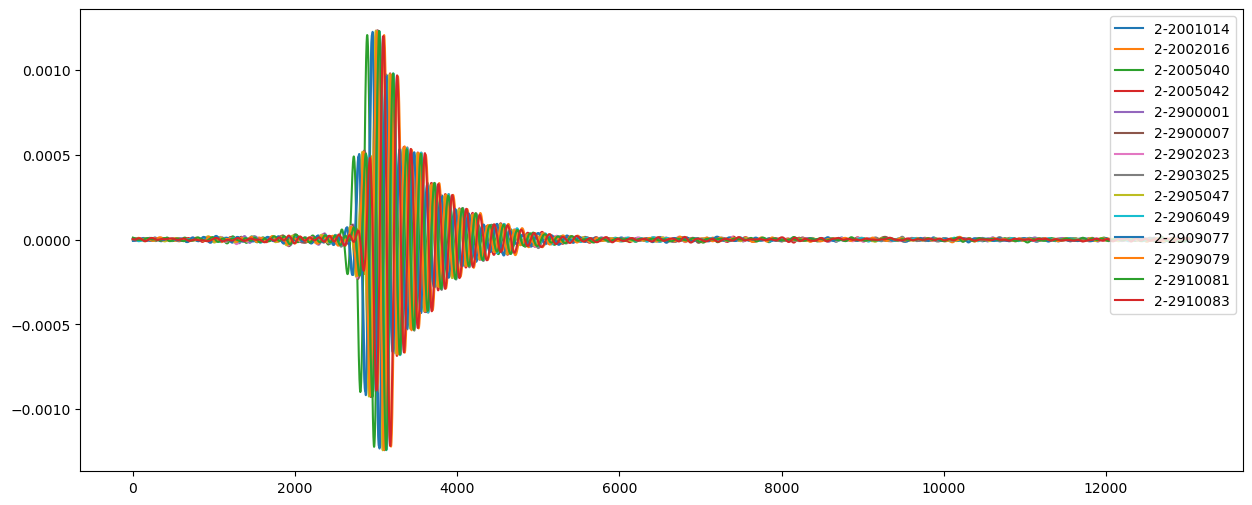

In [20]:
detect_signal(evt, 01.2e-3)

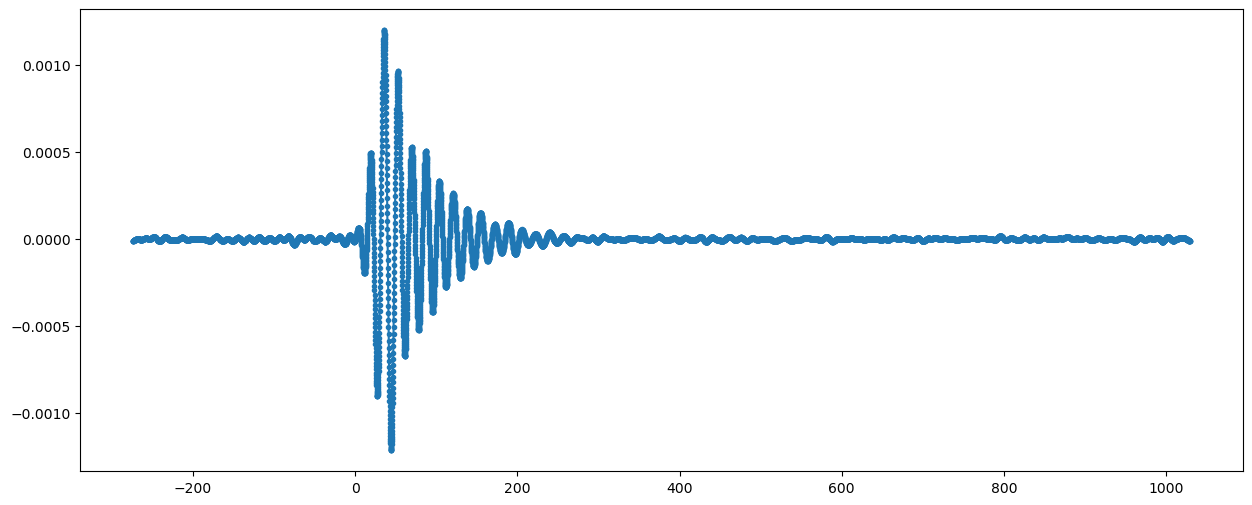

In [18]:
plt.figure(figsize=(15,6))
select_channel = evt.get_station(2).get_channel(2002016)
time = select_channel.get_times()
trace = select_channel.get_trace()
plt.scatter(time, trace, marker='.')
plt.plot(time, trace)
plt.show()

In [8]:
def extract_signal(nbins, trace):
    dur = nbins*50//2
    am = np.argmax(trace)
    if dur > len(trace)//2:
        print("nbins too large. Cannot extract")
        return None
    elif (dur > am):
        return trace[:2*dur][::50]
    elif (dur > len(trace)-am):
        return trace[-2*dur:][::50]
    else:
        return trace[am-dur:am+dur][::50]

In [19]:
nbins = 200
trace_5ns = extract_signal(nbins, trace)

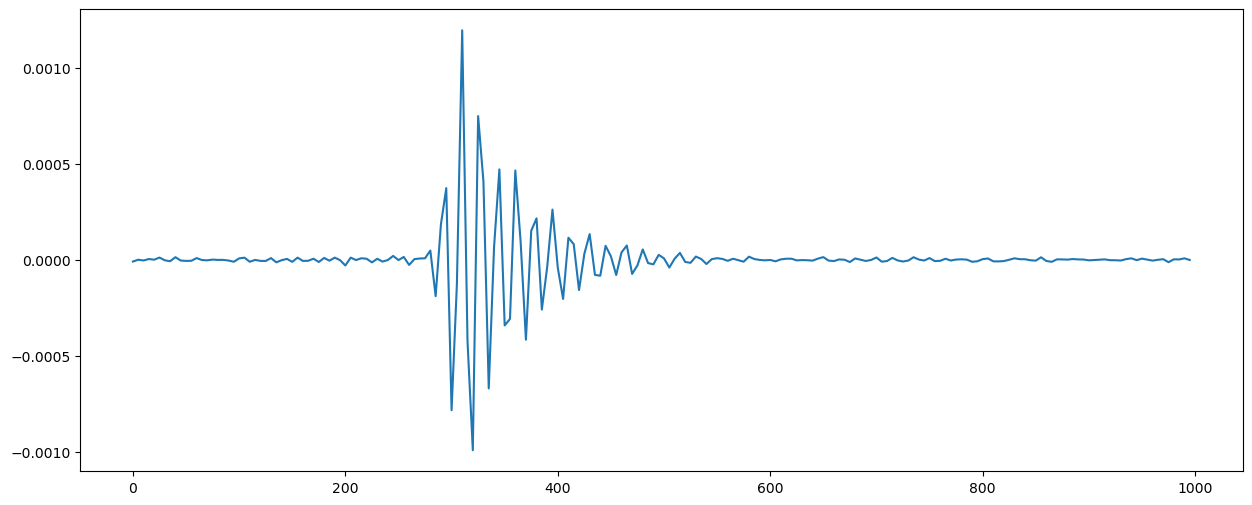

In [20]:
plt.figure(figsize=(15,6))
plt.plot(np.arange(nbins)*5, trace_5ns)

In [22]:
np.save(f"../test_cov/data/trace_{nbins}_simnoise.npy", trace_5ns)
np.save(f"../test_cov/data/time_{nbins}.npy", np.arange(nbins)*5)

In [11]:
reader0 = NuRadioRecoReader(det,filt_settings={"passband": [30 * units.MHz, 80 * units.MHz], "filter_type": "butter", "order": 10})
evt0 = reader0.read_data_event_with_noise(path_to_coreas_sim_file, selected_station_channel_ids=selected_station_channel_ids, core=core_xy, Tnoise=0 * units.K)

WARNING - 2026-08-03 15:23:53,962 - NuRadioReco.detector - Cable delay not set for channel 1000000 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,963 - NuRadioReco.detector - Cable delay not set for channel 1000001 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,963 - NuRadioReco.detector - Cable delay not set for channel 1000002 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,964 - NuRadioReco.detector - Cable delay not set for channel 1000003 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,964 - NuRadioReco.detector - Cable delay not set for channel 1000004 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,964 - NuRadioReco.detector - Cable delay not set for channel 1000005 in station 1, assuming cable delay is zero
WARNING - 2026-08-03 15:23:53,965 - NuRadioReco.detector - Cable delay not set for channel 1000006 in station 1, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-08-03 15:23:57,252 - NuRadioReco.detector - Cable delay not set for channel 2000000 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,253 - NuRadioReco.detector - Cable delay not set for channel 2000001 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,253 - NuRadioReco.detector - Cable delay not set for channel 2000002 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,254 - NuRadioReco.detector - Cable delay not set for channel 2000003 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,254 - NuRadioReco.detector - Cable delay not set for channel 2000004 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,255 - NuRadioReco.detector - Cable delay not set for channel 2000005 in station 2, assuming cable delay is zero
WARNING - 2026-08-03 15:23:57,255 - NuRadioReco.detector - Cable delay not set for channel 2000006 in station 2, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-08-03 15:24:00,864 - NuRadioReco.detector - Cable delay not set for channel 3000000 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,864 - NuRadioReco.detector - Cable delay not set for channel 3000001 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,865 - NuRadioReco.detector - Cable delay not set for channel 3000002 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,865 - NuRadioReco.detector - Cable delay not set for channel 3000003 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,866 - NuRadioReco.detector - Cable delay not set for channel 3000004 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,866 - NuRadioReco.detector - Cable delay not set for channel 3000005 in station 3, assuming cable delay is zero
WARNING - 2026-08-03 15:24:00,867 - NuRadioReco.detector - Cable delay not set for channel 3000006 in station 3, assuming cable delay is zero
WARNIN

...

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-08-03 15:24:10,259 - NuRadioReco.detector - Cable delay not set for channel 6000000 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,260 - NuRadioReco.detector - Cable delay not set for channel 6000001 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,260 - NuRadioReco.detector - Cable delay not set for channel 6000002 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,260 - NuRadioReco.detector - Cable delay not set for channel 6000003 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,261 - NuRadioReco.detector - Cable delay not set for channel 6000004 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,261 - NuRadioReco.detector - Cable delay not set for channel 6000005 in station 6, assuming cable delay is zero
WARNING - 2026-08-03 15:24:10,261 - NuRadioReco.detector - Cable delay not set for channel 6000006 in station 6, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


WARNING - 2026-08-03 15:24:12,708 - NuRadioReco.detector - Cable delay not set for channel 7000000 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,709 - NuRadioReco.detector - Cable delay not set for channel 7000001 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,709 - NuRadioReco.detector - Cable delay not set for channel 7000002 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,710 - NuRadioReco.detector - Cable delay not set for channel 7000003 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,710 - NuRadioReco.detector - Cable delay not set for channel 7000004 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,710 - NuRadioReco.detector - Cable delay not set for channel 7000005 in station 7, assuming cable delay is zero
WARNING - 2026-08-03 15:24:12,711 - NuRadioReco.detector - Cable delay not set for channel 7000006 in station 7, assuming cable delay is zero
WARNIN

Calculated Vrms: 0.00e+00 V, applying noise with amplitude 0.00e+00 V


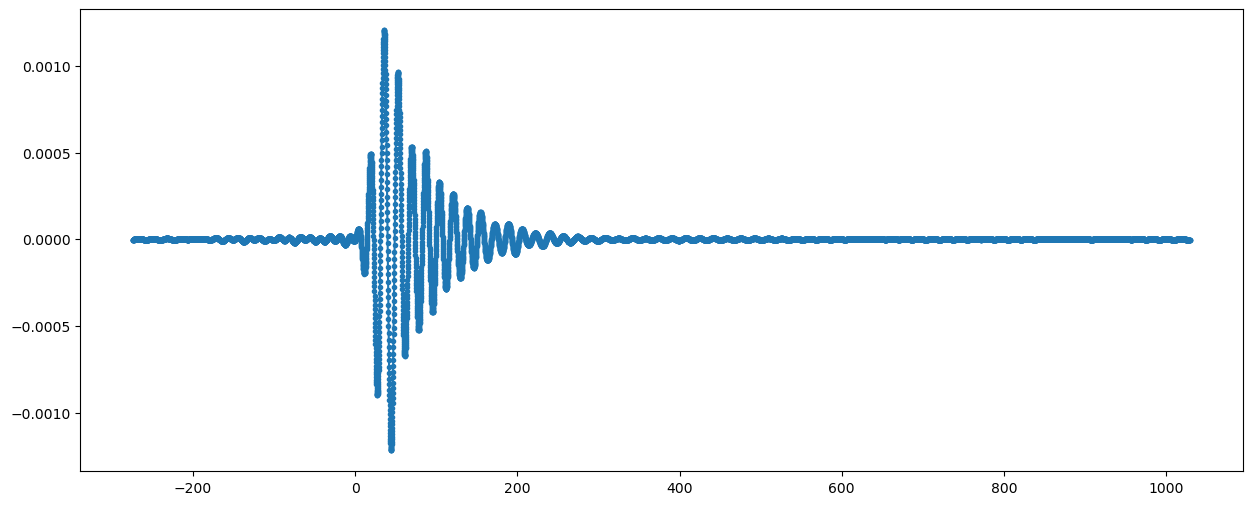

In [13]:
plt.figure(figsize=(15,6))
select_channel = evt0.get_station(2).get_channel(2002016)
time = select_channel.get_times()
trace0 = select_channel.get_trace()
plt.scatter(time, trace0, marker='.')
plt.plot(time, trace0)
plt.show()

In [14]:
trace0_5ns = extract_signal(nbins, trace0)

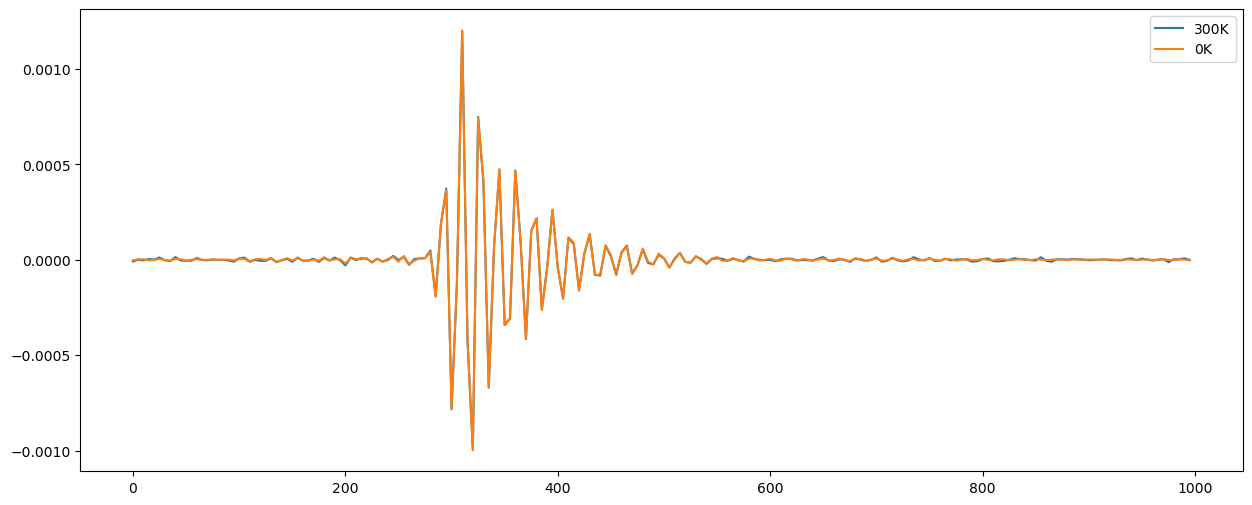

In [21]:
plt.figure(figsize=(15,6))
plt.plot(np.arange(nbins)*5, trace_5ns, label="300K")
plt.plot(np.arange(nbins)*5, trace0_5ns, label="0K")
plt.legend()
plt.show()

In [12]:
st0 = evt0.get_station(6)
chan0 = st0.get_channel(st0.get_channel_ids()[45])

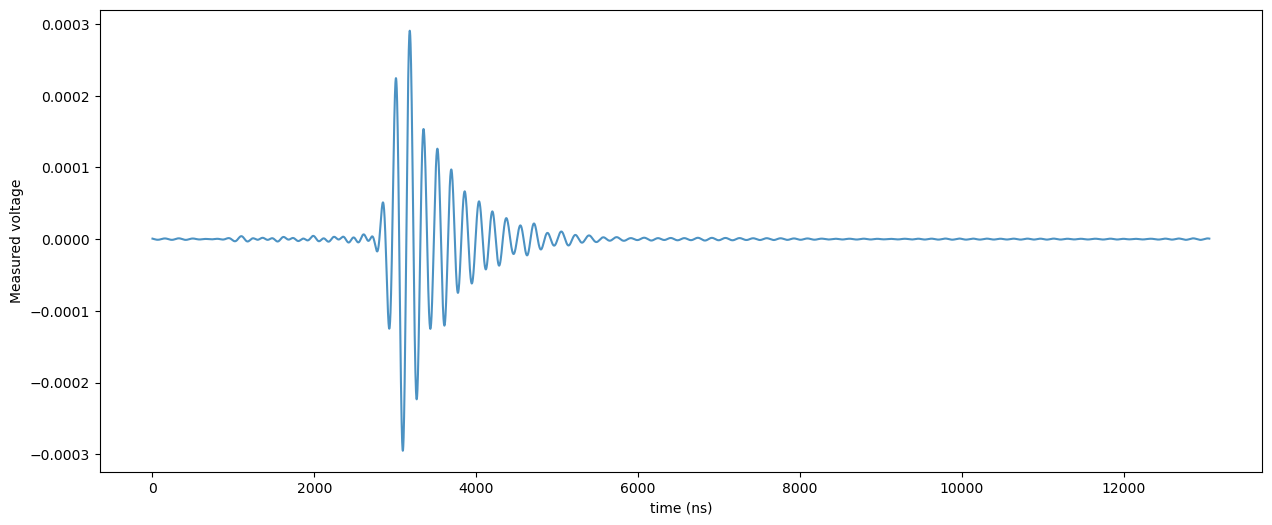

In [9]:
plt.figure(figsize=(15, 6))
# plt.plot(channel.get_trace(), label="300K")
plt.plot(chan0.get_trace(), label="0K", alpha=0.8)
# plt.legend()
plt.xlabel("time (ns)")
plt.ylabel("Measured voltage")
plt.savefig("pure_signal.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
len(st0.get_channel_ids())

192

In [12]:
stations = list(evt0.get_stations())

traces = np.stack([
    np.stack([
        channel.get_trace()
        for channel in station.iter_channels()
    ])
    for station in stations
])

ValueError: all input arrays must have the same shape

In [17]:
for station in evt0.get_stations():
    print(len(station.get_channel_ids()))

192
192
192
192
192
192
192


In [14]:
for station in evt0.get_stations():
    print(
        station.get_id(),
        [channel.get_trace().shape for channel in station.iter_channels()]
    )

1 [(13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,), (13046,